In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# COVID-19 EDA Based on 6 Key Objectives
# Load dataset
df = pd.read_csv("python.raw data.csv")

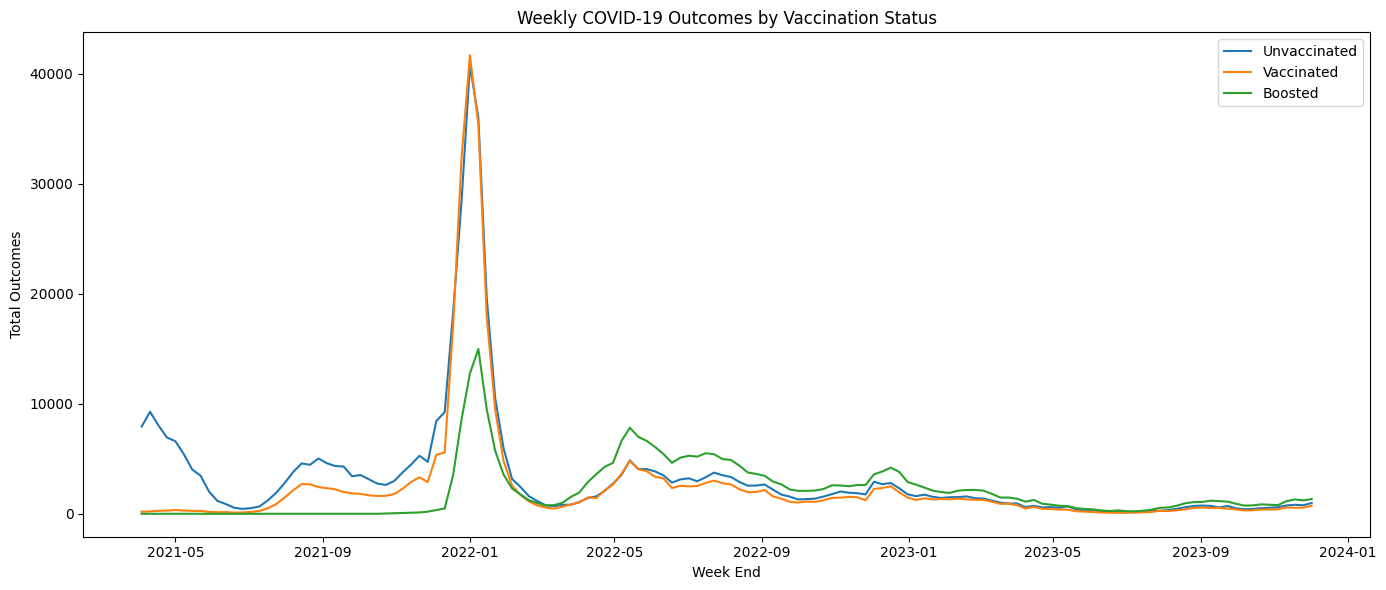

In [6]:
# 1. Weekly Trend by Vaccination
df['Week End'] = pd.to_datetime(df['Week End'], errors='coerce')
df.columns = df.columns.str.strip().str.replace(' +', ' ', regex=True)

weekly_trend = df.groupby('Week End')[['Outcome Unvaccinated', 'Outcome Vaccinated', 'Outcome Boosted']].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_trend, x='Week End', y='Outcome Unvaccinated', label='Unvaccinated')
sns.lineplot(data=weekly_trend, x='Week End', y='Outcome Vaccinated', label='Vaccinated')
sns.lineplot(data=weekly_trend, x='Week End', y='Outcome Boosted', label='Boosted')
plt.title("Weekly COVID-19 Outcomes by Vaccination Status")
plt.xlabel("Week End")
plt.ylabel("Total Outcomes")
plt.legend()
plt.tight_layout()
plt.show()

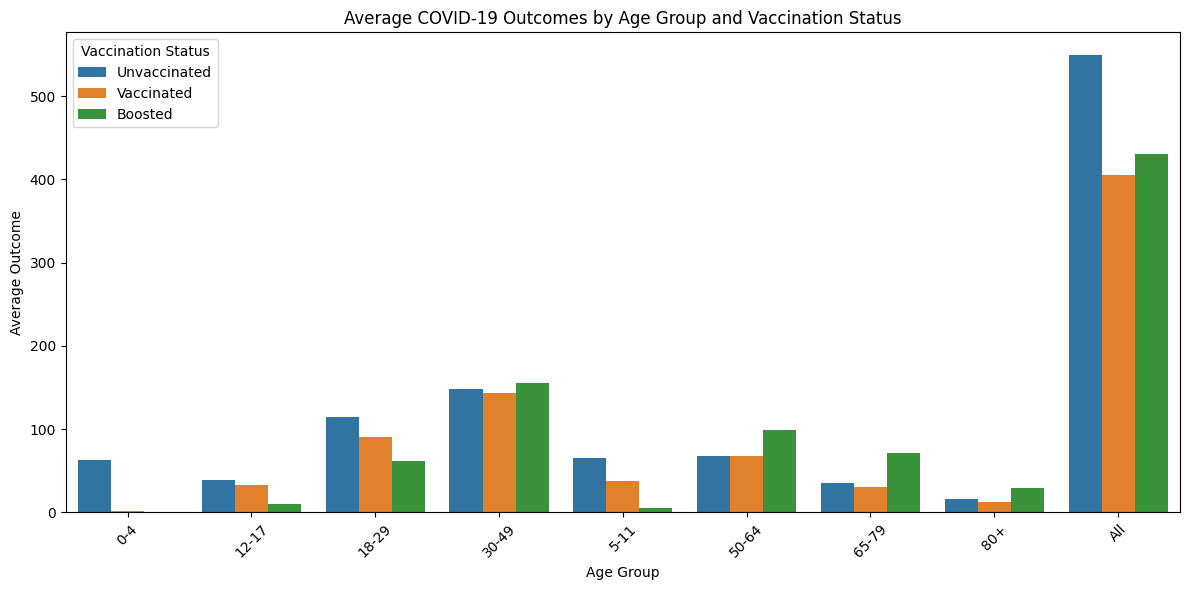

In [7]:
# 2. Outcome Distribution by Age Group
age_group_outcomes = df.groupby("Age Group")[['Outcome Unvaccinated', 'Outcome Vaccinated', 'Outcome Boosted']].mean().reset_index()
age_group_melted = age_group_outcomes.melt(id_vars="Age Group", var_name="Vaccination Status", value_name="Avg Outcome")
age_group_melted["Vaccination Status"] = age_group_melted["Vaccination Status"].str.replace("Outcome ", "")

plt.figure(figsize=(12, 6))
sns.barplot(data=age_group_melted, x="Age Group", y="Avg Outcome", hue="Vaccination Status")
plt.title("Average COVID-19 Outcomes by Age Group and Vaccination Status")
plt.ylabel("Average Outcome")
plt.xlabel("Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

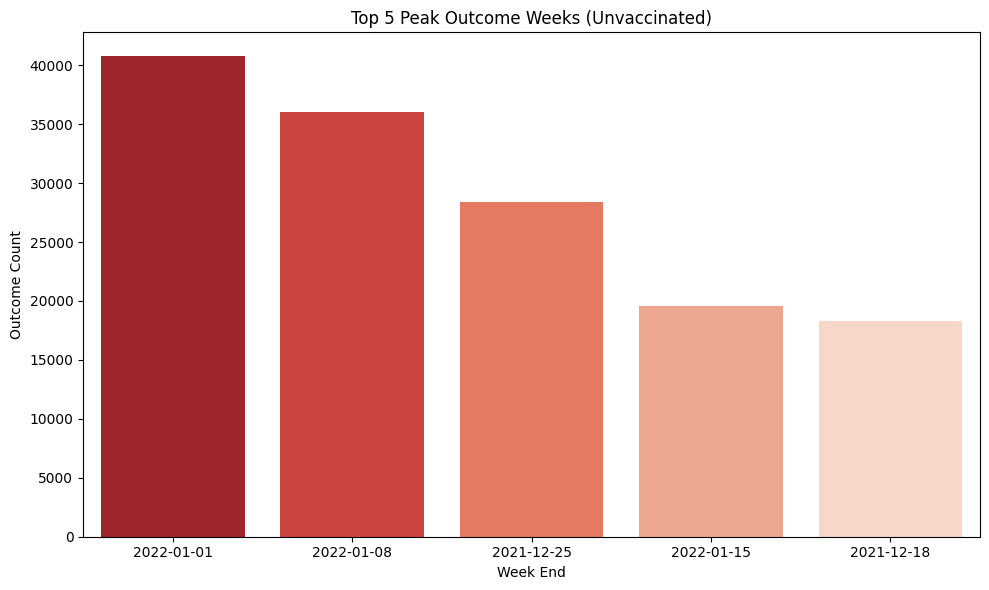

In [8]:
# 3. Top 5 Peak Outcome Weeks (Unvaccinated)
top_weeks = df.groupby("Week End")["Outcome Unvaccinated"].sum().sort_values(ascending=False).head(5)
top_weeks_df = top_weeks.reset_index()
top_weeks_df["Week"] = top_weeks_df["Week End"].dt.strftime("%Y-%m-%d")

plt.figure(figsize=(10, 6))
sns.barplot(data=top_weeks_df, x="Week", y="Outcome Unvaccinated", hue="Week", palette="Reds_r", legend=False)
plt.title("Top 5 Peak Outcome Weeks (Unvaccinated)")
plt.ylabel("Outcome Count")
plt.xlabel("Week End")
plt.tight_layout()
plt.show()

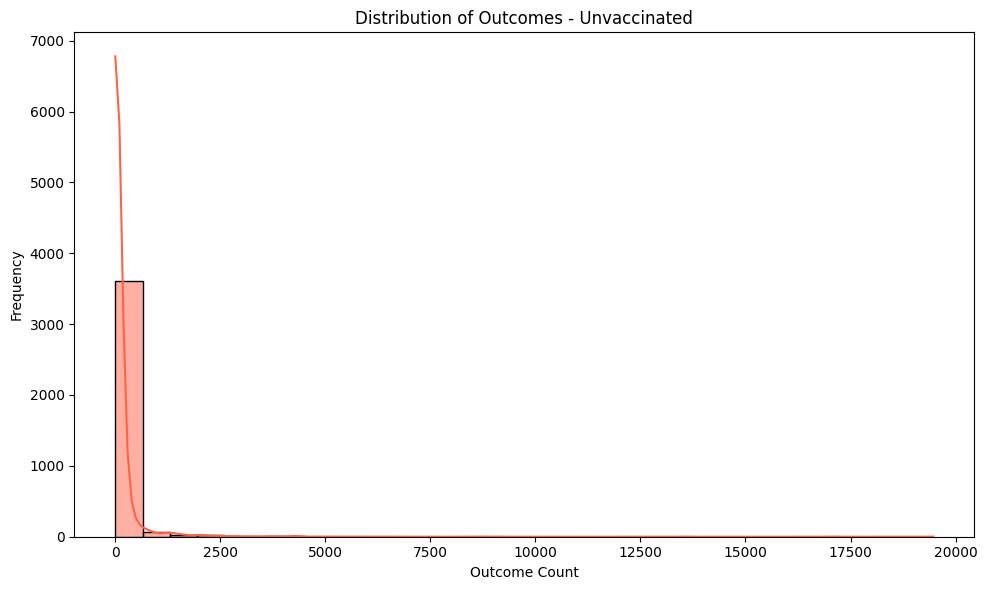

In [9]:
# 4. Distribution of Outcomes (Unvaccinated)
plt.figure(figsize=(10, 6))
sns.histplot(df['Outcome Unvaccinated'], bins=30, kde=True, color='tomato')
plt.title("Distribution of Outcomes - Unvaccinated")
plt.xlabel("Outcome Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

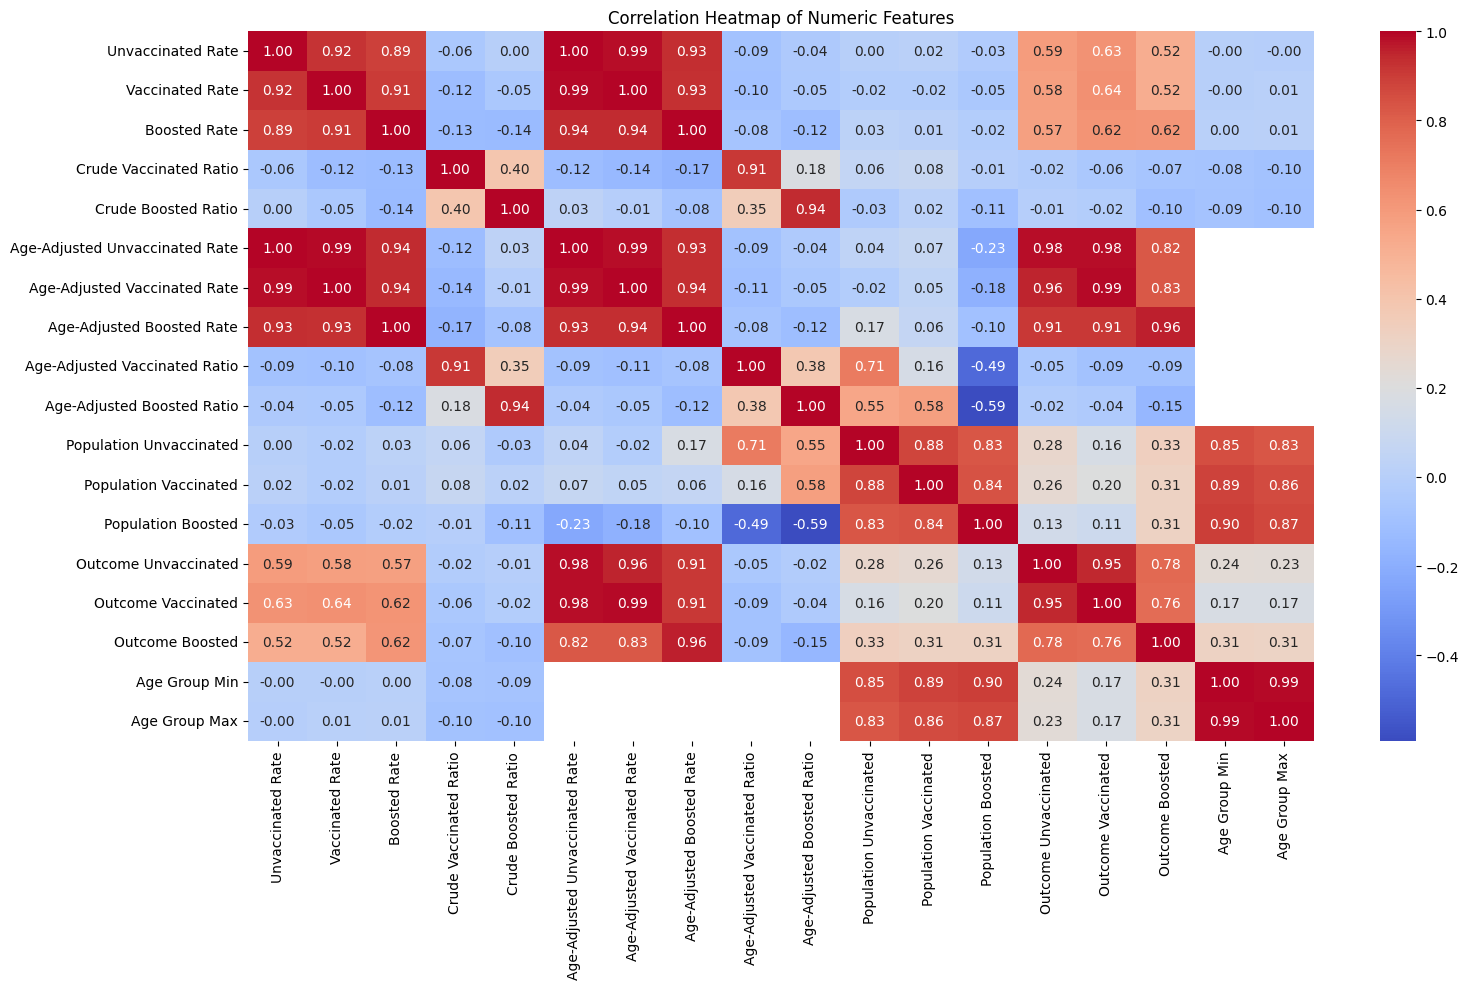

In [10]:

# 5. Correlation Heatmap for Numeric Features
plt.figure(figsize=(16, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


Total COVID-19 Outcomes by Vaccination Status:
Unvaccinated: 458,030
Vaccinated: 338,222.0
Boosted: 283,912.0


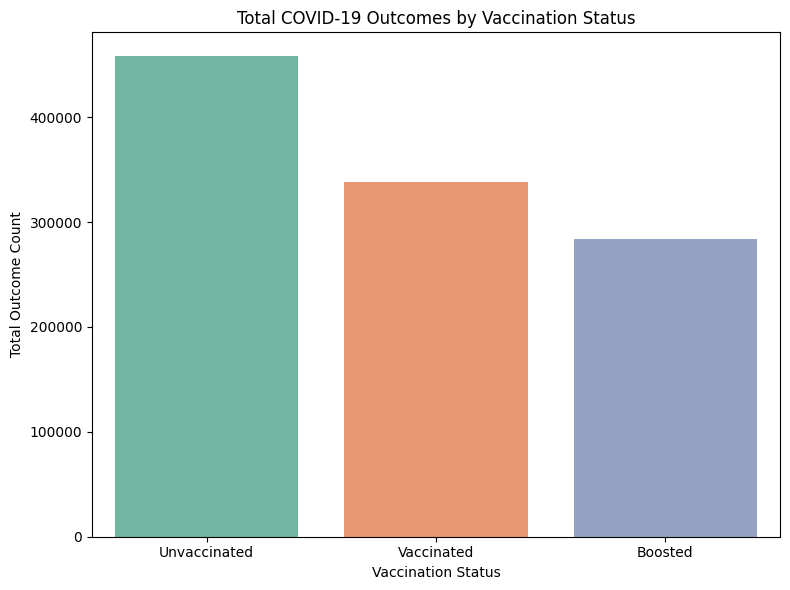

In [11]:
# 6. KPI Summary – Total Outcomes
total_outcomes = {
    'Unvaccinated': df['Outcome Unvaccinated'].sum(),
    'Vaccinated': df['Outcome Vaccinated'].sum(),
    'Boosted': df['Outcome Boosted'].sum()
}

print("\nTotal COVID-19 Outcomes by Vaccination Status:")
for status, value in total_outcomes.items():
    print(f"{status}: {value:,}")

plt.figure(figsize=(8, 6))
total_outcomes_df = pd.DataFrame({"Vaccination Status": list(total_outcomes.keys()), "Total Outcomes": list(total_outcomes.values())})
sns.barplot(data=total_outcomes_df, x="Vaccination Status", y="Total Outcomes", hue="Vaccination Status", palette="Set2", legend=False)
plt.title("Total COVID-19 Outcomes by Vaccination Status")
plt.ylabel("Total Outcome Count")
plt.tight_layout()
plt.show()